# GAT Session Recommendation Results Presentation

This notebook presents the GAT-based session recommendation experiments as a results story:

1. Compare the **best achieved trained results** against the matching published baseline.
2. Explain how each model evolved across result iterations.
3. Keep pending work explicit, especially fourth-iteration `GAT-TAGNN`.


## Executive Summary

- **GAT-SR-GNN** best Yoochoose run is `results-1`: MRR@20 31.146 (+0.206 vs SR-GNN) and Precision@20 70.124 (-0.446).
- **GAT-SR-GNN** best Diginetica run is `results-3`: Precision@20 50.736 (+0.006 vs SR-GNN), with MRR@20 -0.735 below SR-GNN.
- **GAT-TAGNN** best runs are still from `results-1`: Yoochoose MRR@20 is -0.116 vs TAGNN and Diginetica MRR@20 is -0.677 vs TAGNN.
- Fourth-iteration TAGNN is not claimed yet because that model has not been trained for `results-4`.


## Result Iterations

| Iteration | Folder | GAT-SR-GNN status | GAT-TAGNN status | What Changed |
| --- | --- | --- | --- | --- |
| 1 | results-1 | trained | trained | Initial complete GAT-SR-GNN and GAT-TAGNN archive used as the first working reference point. |
| 2 | results-2 | trained | pending | Simplified GAT stack revision; only GAT-SR-GNN was rerun in this export. |
| 3 | results-3 | trained | trained | GATv2/performance iteration, including TAGNN scoring/chunking changes and SR-GNN positional-embedding rollback. |
| 4 | results-4 | trained | pending | Repeated transition edges plus explicit residual connections in the GAT stack; TAGNN still pending. |


## Best Achieved Results vs Published Baselines

The main comparison selects the best trained run for each model and dataset by `MRR@20`, using `Precision@20` as a tie-breaker. `GAT-SR-GNN` is compared with the published **SR-GNN** row; `GAT-TAGNN` is compared with the published **TAGNN** row.

| Model | Dataset | Best Run | Paper Baseline | Precision@20 | Baseline P@20 | Delta P@20 | MRR@20 | Baseline MRR@20 | Delta MRR@20 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| GAT-SR-GNN | Diginetica | results-3 | SR-GNN | 50.736 | 50.730 | 0.006 | 16.855 | 17.590 | -0.735 |
| GAT-SR-GNN | Yoochoose 1/64 | results-1 | SR-GNN | 70.124 | 70.570 | -0.446 | 31.146 | 30.940 | 0.206 |
| GAT-TAGNN | Diginetica | results-1 | TAGNN | 51.252 | 51.310 | -0.058 | 17.353 | 18.030 | -0.677 |
| GAT-TAGNN | Yoochoose 1/64 | results-1 | TAGNN | 70.611 | 71.020 | -0.409 | 31.004 | 31.120 | -0.116 |


![Best GAT results compared with published baselines](results-analysis/best_vs_baseline.png)

![Best-result deltas from the matching published baseline](results-analysis/best_delta_vs_baseline.png)


## Model Evolution: GAT-SR-GNN

`GAT-SR-GNN` has a complete four-iteration trace. The first archive remains strongest on Yoochoose, while Diginetica peaks in the third iteration. The fourth iteration is still useful evidence: it tests repeated transition edges plus explicit residual connections, but it does not improve final test metrics over the best previous run.


| Dataset | Run | Status | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- | --- | --- |
| Diginetica | results-1 | trained | 50.250 | 16.646 | 4 | 19.413 |
| Diginetica | results-2 | trained | 50.629 | 16.725 | 28 | 19.486 |
| Diginetica | results-3 | trained | 50.736 | 16.855 | 19 | 19.563 |
| Diginetica | results-4 | trained | 50.454 | 16.802 | 19 | 19.529 |
| Yoochoose 1/64 | results-1 | trained | 70.124 | 31.146 | 9 | 32.706 |
| Yoochoose 1/64 | results-2 | trained | 68.729 | 30.355 | 29 | 31.680 |
| Yoochoose 1/64 | results-3 | trained | 68.942 | 30.563 | 25 | 31.759 |
| Yoochoose 1/64 | results-4 | trained | 68.754 | 30.595 | 27 | 31.767 |

![GAT-SR-GNN metric evolution](results-analysis/gat_sr_gnn_evolution.png)

## Model Evolution: GAT-TAGNN

`GAT-TAGNN` has trained exports for iterations 1 and 3. Iterations 2 and 4 remain pending, so the notebook does not make claims for those runs.


| Dataset | Run | Status | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- | --- | --- |
| Diginetica | results-1 | trained | 51.252 | 17.353 | 4 | 19.651 |
| Diginetica | results-2 | pending |  |  |  |  |
| Diginetica | results-3 | trained | 50.925 | 17.128 | 25 | 19.505 |
| Diginetica | results-4 | pending |  |  |  |  |
| Yoochoose 1/64 | results-1 | trained | 70.611 | 31.004 | 10 | 32.669 |
| Yoochoose 1/64 | results-2 | pending |  |  |  |  |
| Yoochoose 1/64 | results-3 | trained | 68.591 | 29.892 | 30 | 31.336 |
| Yoochoose 1/64 | results-4 | pending |  |  |  |  |

![GAT-TAGNN metric evolution](results-analysis/gat_tagnn_evolution.png)

## Validation Curves

The validation curves are supporting diagnostics for the exported checkpoints. The main comparison remains the held-out test `Precision@20` and `MRR@20` above.


![GAT-SR-GNN validation history](results-analysis/gat_sr_gnn_validation_history.png)

![GAT-TAGNN validation history](results-analysis/gat_tagnn_validation_history.png)


## Exploratory GAT-SAGPool Snapshot

`GAT-SAGPool` is kept separate because it is not a direct SR-GNN-readout or TAGNN-readout replacement. It is useful as an exploratory fully attention-based branch, but it should not be used as the controlled GGNN-vs-GAT claim.

| Dataset | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- |
| Yoochoose 1/64 | 70.185 | 30.882 | 7 | 32.571 |
| Diginetica | 50.427 | 16.743 | 4 | 19.490 |


## Reproducibility: Build Tables and Plots

The cells below rebuild every table and figure used above directly from the archived result folders. Running them updates the derived files under `results-analysis/`, including the main best-vs-baseline plots and the per-model evolution plots.

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
PRESENTATION_DIR = PROJECT_ROOT / "results-analysis"
PRESENTATION_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format

BASELINE_ROWS = [
    ("POP", 6.71, 1.65, 0.89, 0.20),
    ("S-POP", 30.44, 18.35, 21.06, 13.68),
    ("Item-KNN", 51.60, 21.81, 35.75, 11.57),
    ("BPR-MF", 31.31, 12.08, 5.24, 1.98),
    ("FPMC", 45.62, 15.01, 26.53, 6.95),
    ("GRU4REC", 60.64, 22.89, 29.45, 8.33),
    ("NARM", 68.32, 28.63, 49.70, 16.17),
    ("STAMP", 68.74, 29.67, 45.64, 14.32),
    ("SR-GNN", 70.57, 30.94, 50.73, 17.59),
    ("TAGNN", 71.02, 31.12, 51.31, 18.03),
]
BASELINE_COLUMNS = [
    "method",
    "yoochoose_1_64_precision@20",
    "yoochoose_1_64_mrr@20",
    "diginetica_precision@20",
    "diginetica_mrr@20",
]
baselines = pd.DataFrame(BASELINE_ROWS, columns=BASELINE_COLUMNS)

ITERATIONS = [
    {
        "iteration": 1,
        "folder": "results-1",
        "GAT-SR-GNN status": "trained",
        "GAT-TAGNN status": "trained",
        "What Changed": "Initial complete GAT-SR-GNN and GAT-TAGNN archive used as the first working reference point.",
    },
    {
        "iteration": 2,
        "folder": "results-2",
        "GAT-SR-GNN status": "trained",
        "GAT-TAGNN status": "pending",
        "What Changed": "Simplified GAT stack revision; only GAT-SR-GNN was rerun in this export.",
    },
    {
        "iteration": 3,
        "folder": "results-3",
        "GAT-SR-GNN status": "trained",
        "GAT-TAGNN status": "trained",
        "What Changed": "GATv2/performance iteration, including TAGNN scoring/chunking changes and SR-GNN positional-embedding rollback.",
    },
    {
        "iteration": 4,
        "folder": "results-4",
        "GAT-SR-GNN status": "trained",
        "GAT-TAGNN status": "pending",
        "What Changed": "Repeated transition edges plus explicit residual connections in the GAT stack; TAGNN still pending.",
    },
]
iteration_status = pd.DataFrame(ITERATIONS)
iteration_status.to_csv(PRESENTATION_DIR / "iteration_status.csv", index=False)

REFERENCE_BY_MODEL = {"GAT-SR-GNN": "SR-GNN", "GAT-TAGNN": "TAGNN"}
DATASET_KEY = {"Yoochoose 1/64": "yoochoose_1_64", "Diginetica": "diginetica"}
EXPECTED_RESULT_COLUMNS = [
    "model",
    "iteration",
    "folder",
    "dataset",
    "test_precision@20",
    "test_mrr@20",
    "test_loss",
    "best_epoch",
    "best_validation_precision@20",
    "best_validation_mrr@20",
    "train_examples",
    "validation_examples",
    "test_examples",
    "num_items",
    "checkpoint_path",
]
iteration_status

,iteration,folder,GAT-SR-GNN status,GAT-TAGNN status,What Changed
0,1,results-1,trained,trained,Initial complete GAT-SR-GNN and GAT-TAGNN arch...
1,2,results-2,trained,pending,Simplified GAT stack revision; only GAT-SR-GNN...
2,3,results-3,trained,trained,"GATv2/performance iteration, including TAGNN s..."
3,4,results-4,trained,pending,Repeated transition edges plus explicit residu...


In [16]:
def load_result_file(path, model, iteration, folder):
    if not path.is_file():
        return None
    df = pd.read_csv(path).assign(model=model, iteration=iteration, folder=folder)
    for column in EXPECTED_RESULT_COLUMNS:
        if column not in df.columns:
            df[column] = pd.NA
    return df[EXPECTED_RESULT_COLUMNS]

run_frames = []
for run in ITERATIONS:
    folder = PROJECT_ROOT / run["folder"]
    for filename, model in [
        ("gat_sr_gnn_results.csv", "GAT-SR-GNN"),
        ("gat_tagnn_results.csv", "GAT-TAGNN"),
    ]:
        loaded = load_result_file(folder / filename, model, run["iteration"], run["folder"])
        if loaded is not None:
            run_frames.append(loaded)

all_runs = (
    pd.concat(run_frames, ignore_index=True)
    .sort_values(["model", "dataset", "iteration"])
    .reset_index(drop=True)
)
all_runs.to_csv(PRESENTATION_DIR / "all_model_runs.csv", index=False)
all_runs

,model,iteration,folder,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path
0,GAT-SR-GNN,1,results-1,Diginetica,50.250,16.646,5.553,4,55.795,19.413,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
1,GAT-SR-GNN,2,results-2,Diginetica,50.629,16.725,5.657,28,55.207,19.486,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
2,GAT-SR-GNN,3,results-3,Diginetica,50.736,16.855,5.654,19,55.478,19.563,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
3,GAT-SR-GNN,4,results-4,Diginetica,50.454,16.802,5.664,19,55.243,19.529,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
4,GAT-SR-GNN,1,results-1,Yoochoose 1/64,70.124,31.146,4.342,9,69.474,32.706,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
5,GAT-SR-GNN,2,results-2,Yoochoose 1/64,68.729,30.355,4.455,29,66.873,31.680,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
6,GAT-SR-GNN,3,results-3,Yoochoose 1/64,68.942,30.563,4.451,25,66.903,31.759,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
7,GAT-SR-GNN,4,results-4,Yoochoose 1/64,68.754,30.595,4.455,27,66.754,31.767,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
8,GAT-TAGNN,1,results-1,Diginetica,51.252,17.353,5.522,4,55.749,19.651,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_tagnn_...
9,GAT-TAGNN,3,results-3,Diginetica,50.925,17.128,5.617,25,55.268,19.505,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_tagnn_...


In [17]:
best_rows = []
for (model, dataset), group in all_runs.groupby(["model", "dataset"], sort=False):
    best = group.sort_values(
        ["test_mrr@20", "test_precision@20", "iteration"],
        ascending=[False, False, False],
    ).iloc[0]
    reference_method = REFERENCE_BY_MODEL[model]
    dataset_key = DATASET_KEY[dataset]
    reference_precision = baselines.loc[
        baselines["method"] == reference_method,
        f"{dataset_key}_precision@20",
    ].iloc[0]
    reference_mrr = baselines.loc[
        baselines["method"] == reference_method,
        f"{dataset_key}_mrr@20",
    ].iloc[0]
    best_rows.append({
        "model": model,
        "dataset": dataset,
        "best_iteration": int(best["iteration"]),
        "folder": best["folder"],
        "reference_method": reference_method,
        "test_precision@20": best["test_precision@20"],
        "reference_precision@20": reference_precision,
        "delta_precision@20": best["test_precision@20"] - reference_precision,
        "test_mrr@20": best["test_mrr@20"],
        "reference_mrr@20": reference_mrr,
        "delta_mrr@20": best["test_mrr@20"] - reference_mrr,
        "best_epoch": best["best_epoch"],
        "best_validation_mrr@20": best["best_validation_mrr@20"],
    })

best_vs_baseline = (
    pd.DataFrame(best_rows)
    .sort_values(["model", "dataset"])
    .reset_index(drop=True)
)
best_vs_baseline.to_csv(PRESENTATION_DIR / "best_vs_baseline.csv", index=False)
best_vs_baseline

,model,dataset,best_iteration,folder,reference_method,test_precision@20,reference_precision@20,delta_precision@20,test_mrr@20,reference_mrr@20,delta_mrr@20,best_epoch,best_validation_mrr@20
0,GAT-SR-GNN,Diginetica,3,results-3,SR-GNN,50.736,50.730,0.006,16.855,17.590,-0.735,19,19.563
1,GAT-SR-GNN,Yoochoose 1/64,1,results-1,SR-GNN,70.124,70.570,-0.446,31.146,30.940,0.206,9,32.706
2,GAT-TAGNN,Diginetica,1,results-1,TAGNN,51.252,51.310,-0.058,17.353,18.030,-0.677,4,19.651
3,GAT-TAGNN,Yoochoose 1/64,1,results-1,TAGNN,70.611,71.020,-0.409,31.004,31.120,-0.116,10,32.669


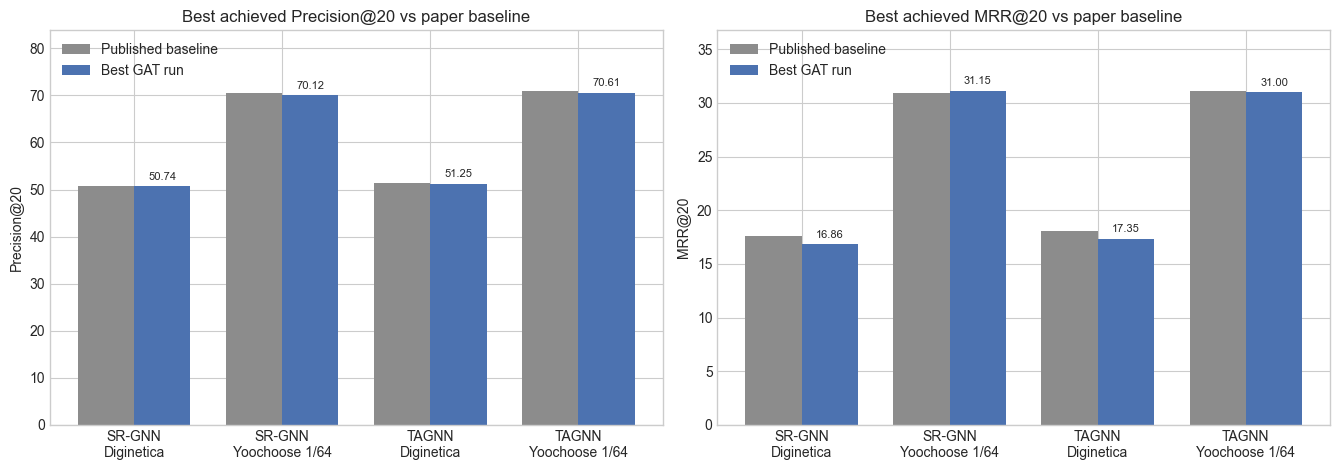

In [18]:
plot_best = best_vs_baseline.copy()
plot_best["label"] = (
    plot_best["model"].str.replace("GAT-", "", regex=False)
    + "\n"
    + plot_best["dataset"]
)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
plot_specs = [
    (
        "test_precision@20",
        "reference_precision@20",
        "Precision@20",
        "Best achieved Precision@20 vs paper baseline",
    ),
    (
        "test_mrr@20",
        "reference_mrr@20",
        "MRR@20",
        "Best achieved MRR@20 vs paper baseline",
    ),
]
for ax, (metric, reference_metric, ylabel, title) in zip(axes, plot_specs):
    x_positions = list(range(len(plot_best)))
    width = 0.38
    ax.bar(
        [x - width / 2 for x in x_positions],
        plot_best[reference_metric],
        width=width,
        label="Published baseline",
        color="#8c8c8c",
    )
    bars = ax.bar(
        [x + width / 2 for x in x_positions],
        plot_best[metric],
        width=width,
        label="Best GAT run",
        color="#4c72b0",
    )
    ax.set_xticks(x_positions, plot_best["label"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.18)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "best_vs_baseline.png", dpi=180, bbox_inches="tight")
plt.show()

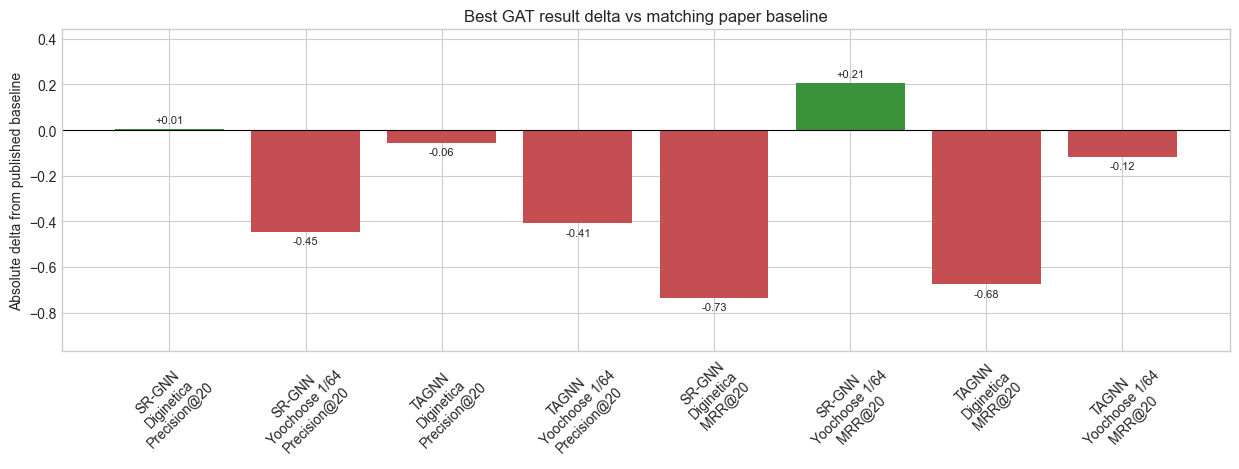

In [19]:
delta_plot = best_vs_baseline.melt(
    id_vars=["model", "dataset", "best_iteration"],
    value_vars=["delta_precision@20", "delta_mrr@20"],
    var_name="metric",
    value_name="delta",
)
delta_plot["metric"] = delta_plot["metric"].map({
    "delta_precision@20": "Precision@20",
    "delta_mrr@20": "MRR@20",
})
delta_plot["label"] = (
    delta_plot["model"].str.replace("GAT-", "", regex=False)
    + "\n"
    + delta_plot["dataset"]
    + "\n"
    + delta_plot["metric"]
)
fig, ax = plt.subplots(figsize=(12.5, 4.8))
bars = ax.bar(
    delta_plot["label"],
    delta_plot["delta"],
    color=["#3a923a" if value >= 0 else "#c44e52" for value in delta_plot["delta"]],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Absolute delta from published baseline")
ax.set_title("Best GAT result delta vs matching paper baseline")
ax.tick_params(axis="x", rotation=45)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
ax.margins(y=0.25)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "best_delta_vs_baseline.png", dpi=180, bbox_inches="tight")
plt.show()

In [20]:
evolution_rows = []
for model in ["GAT-SR-GNN", "GAT-TAGNN"]:
    datasets = sorted(all_runs.loc[all_runs["model"] == model, "dataset"].unique())
    for dataset in datasets:
        existing = all_runs[
            (all_runs["model"] == model) & (all_runs["dataset"] == dataset)
        ].set_index("iteration")
        for run in ITERATIONS:
            iteration = run["iteration"]
            if iteration in existing.index:
                record = existing.loc[iteration].to_dict()
                record.update({
                    "model": model,
                    "dataset": dataset,
                    "iteration": int(iteration),
                    "folder": run["folder"],
                    "status": "trained",
                })
            else:
                record = {column: pd.NA for column in EXPECTED_RESULT_COLUMNS}
                record.update({
                    "model": model,
                    "dataset": dataset,
                    "iteration": int(iteration),
                    "folder": run["folder"],
                    "checkpoint_path": "pending rerun",
                    "status": "pending",
                })
            evolution_rows.append(record)

model_evolution = (
    pd.DataFrame(evolution_rows)
    .sort_values(["model", "dataset", "iteration"])
    .reset_index(drop=True)
)
model_evolution.to_csv(PRESENTATION_DIR / "model_evolution.csv", index=False)
model_evolution

,model,folder,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path,iteration,status
0,GAT-SR-GNN,results-1,Diginetica,50.250,16.646,5.553,4,55.795,19.413,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,1,trained
1,GAT-SR-GNN,results-2,Diginetica,50.629,16.725,5.657,28,55.207,19.486,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,2,trained
2,GAT-SR-GNN,results-3,Diginetica,50.736,16.855,5.654,19,55.478,19.563,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,3,trained
3,GAT-SR-GNN,results-4,Diginetica,50.454,16.802,5.664,19,55.243,19.529,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,4,trained
4,GAT-SR-GNN,results-1,Yoochoose 1/64,70.124,31.146,4.342,9,69.474,32.706,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,1,trained
5,GAT-SR-GNN,results-2,Yoochoose 1/64,68.729,30.355,4.455,29,66.873,31.680,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,2,trained
6,GAT-SR-GNN,results-3,Yoochoose 1/64,68.942,30.563,4.451,25,66.903,31.759,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,3,trained
7,GAT-SR-GNN,results-4,Yoochoose 1/64,68.754,30.595,4.455,27,66.754,31.767,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,4,trained
8,GAT-TAGNN,results-1,Diginetica,51.252,17.353,5.522,4,55.749,19.651,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_tagnn_...,1,trained
9,GAT-TAGNN,results-2,Diginetica,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending rerun,2,pending


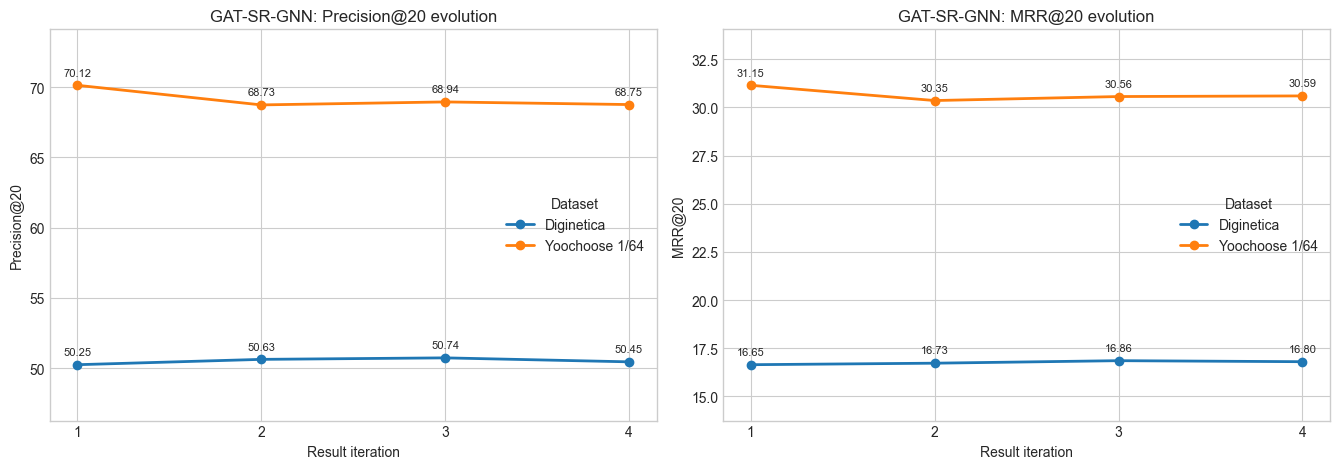

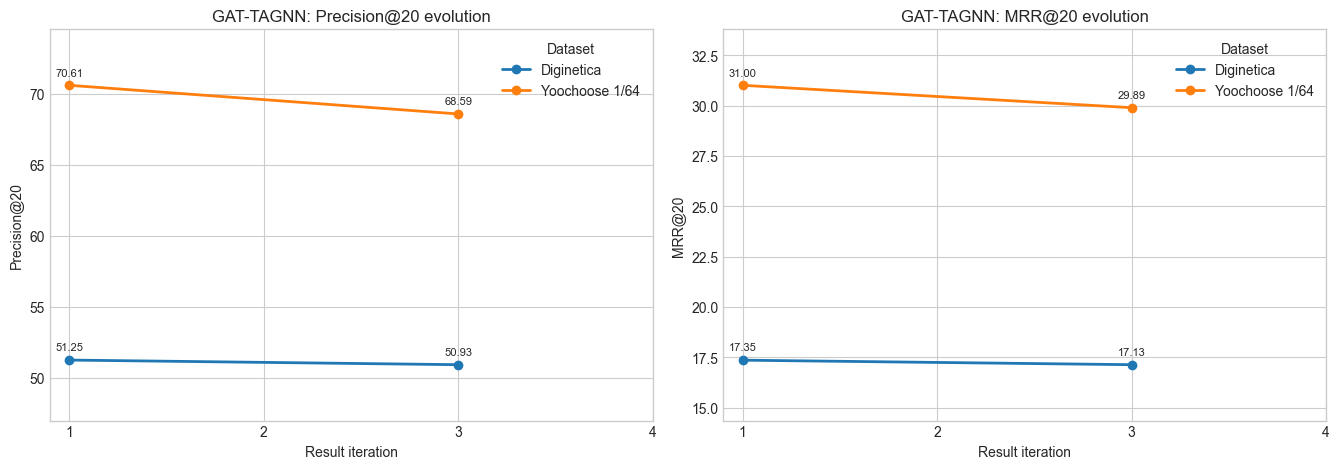

In [21]:
def plot_evolution(model, filename):
    model_runs = model_evolution[
        (model_evolution["model"] == model) & (model_evolution["status"] == "trained")
    ].copy()
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
    for ax, metric, ylabel in [
        (axes[0], "test_precision@20", "Precision@20"),
        (axes[1], "test_mrr@20", "MRR@20"),
    ]:
        for dataset, dataset_runs in model_runs.groupby("dataset"):
            dataset_runs = dataset_runs.sort_values("iteration")
            ax.plot(
                dataset_runs["iteration"],
                dataset_runs[metric],
                marker="o",
                linewidth=2,
                label=dataset,
            )
            for _, row in dataset_runs.iterrows():
                ax.annotate(
                    f"{row[metric]:.2f}",
                    (row["iteration"], row[metric]),
                    xytext=(0, 7),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                )
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xlabel("Result iteration")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{model}: {ylabel} evolution")
        ax.legend(title="Dataset")
        ax.margins(y=0.2)
    fig.tight_layout()
    fig.savefig(PRESENTATION_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_evolution("GAT-SR-GNN", "gat_sr_gnn_evolution.png")
plot_evolution("GAT-TAGNN", "gat_tagnn_evolution.png")

In [22]:
history_frames = []
for run in ITERATIONS:
    for filename, model in [
        ("gat_sr_gnn_history.csv", "GAT-SR-GNN"),
        ("gat_tagnn_history.csv", "GAT-TAGNN"),
    ]:
        path = PROJECT_ROOT / run["folder"] / filename
        if path.is_file():
            history_frames.append(
                pd.read_csv(path).assign(
                    model=model,
                    iteration=int(run["iteration"]),
                    folder=run["folder"],
                )
            )

training_histories = pd.concat(history_frames, ignore_index=True)
training_histories.to_csv(PRESENTATION_DIR / "training_histories.csv", index=False)
training_histories.head()

,dataset,epoch,train_loss,validation_loss,validation_precision@20,validation_mrr@20,epoch_seconds,train_examples,validation_examples,test_examples,model,iteration,folder,learning_rate
0,Yoochoose 1/64,1,5.527,4.725,64.664,28.646,153.680,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
1,Yoochoose 1/64,2,4.456,4.514,67.460,30.068,148.083,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
2,Yoochoose 1/64,3,4.202,4.443,68.468,30.689,147.950,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
3,Yoochoose 1/64,4,3.773,4.346,69.636,32.411,149.080,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
4,Yoochoose 1/64,5,3.680,4.354,69.580,32.568,148.789,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN


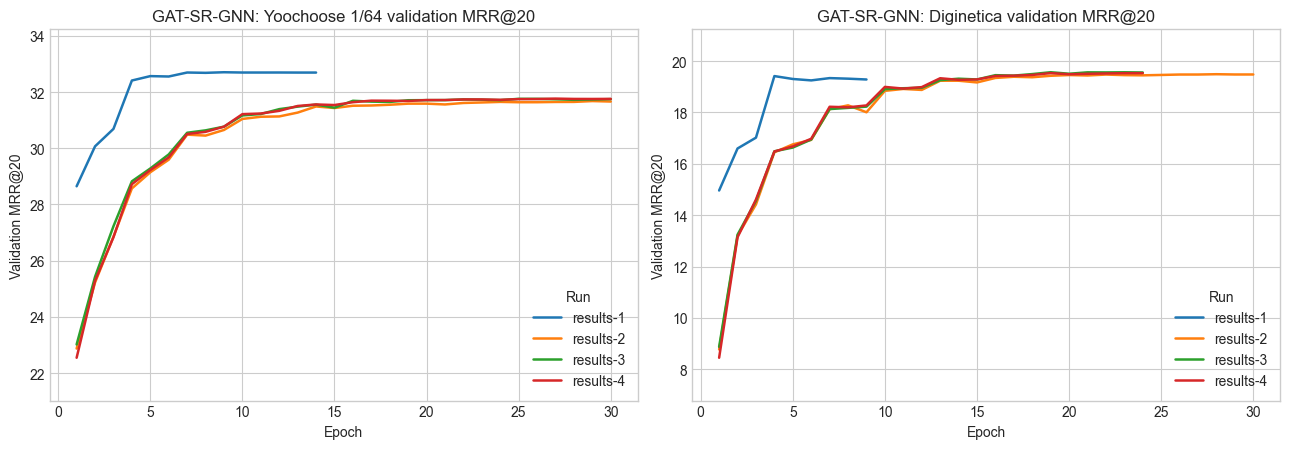

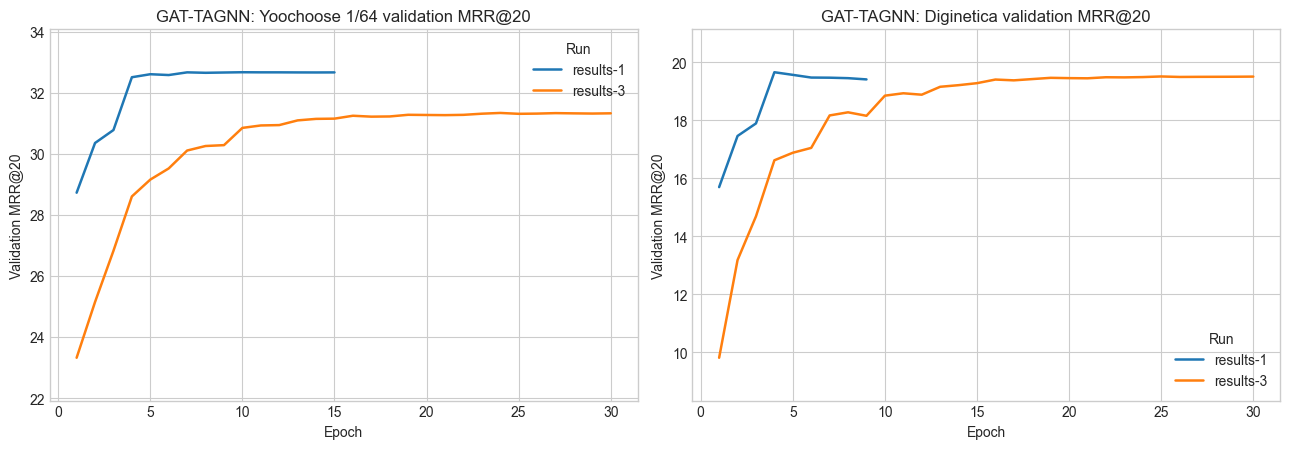

In [23]:
def plot_validation_history(model, filename):
    model_history = training_histories[training_histories["model"] == model].copy()
    datasets = list(model_history["dataset"].drop_duplicates())
    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(6.5 * len(datasets), 4.6),
        squeeze=False,
    )
    for ax, dataset in zip(axes[0], datasets):
        dataset_history = model_history[model_history["dataset"] == dataset]
        for iteration, run_history in dataset_history.groupby("iteration"):
            run_history = run_history.sort_values("epoch")
            ax.plot(
                run_history["epoch"],
                run_history["validation_mrr@20"],
                label=f"results-{iteration}",
                linewidth=1.8,
            )
        ax.set_title(f"{model}: {dataset} validation MRR@20")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation MRR@20")
        ax.legend(title="Run")
        ax.margins(y=0.15)
    fig.tight_layout()
    fig.savefig(PRESENTATION_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_validation_history("GAT-SR-GNN", "gat_sr_gnn_validation_history.png")
plot_validation_history("GAT-TAGNN", "gat_tagnn_validation_history.png")

In [24]:
sagpool_results_path = PROJECT_ROOT / "results-gat-sagpool" / "gat_sagpool_results.csv"
if sagpool_results_path.is_file():
    gat_sagpool_snapshot = pd.read_csv(sagpool_results_path).assign(model="GAT-SAGPool")
    gat_sagpool_snapshot.to_csv(PRESENTATION_DIR / "gat_sagpool_snapshot.csv", index=False)
else:
    gat_sagpool_snapshot = pd.DataFrame()
gat_sagpool_snapshot

,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path,model
0,Yoochoose 1/64,70.185,30.882,4.337,7,69.306,32.571,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sagpoo...,GAT-SAGPool
1,Diginetica,50.427,16.743,5.531,4,55.464,19.490,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sagpoo...,GAT-SAGPool
